# Baseline Benchmarks Notebook

Run the cells top-to-bottom in order. The first cells clone [pranavr11/mls](https://github.com/pranavr11/mls) on the **`kkm`** branch, install requirements, then run the one-example GovReport walkthrough (ROUGE, latency, attention map).


In [43]:
import nbformat
nb = nbformat.read("notebook.ipynb", as_version=nbformat.NO_CONVERT)
if "widgets" in nb.metadata and "state" not in nb.metadata.widgets:
  nb.metadata["widgets"] = {"state": {}}
nbformat.write(nb, "notebook_fixed.ipynb")

FileNotFoundError: [Errno 2] No such file or directory: 'notebook.ipynb'

In [5]:
# Clone pranavr11/mls on branch kkm. If `mls` already exists, remove it first (`!rm -rf mls`)
# or run: %cd mls / !git pull origin kkm
!git clone --branch kkm https://github.com/pranavr11/mls.git


Cloning into 'mls'...
remote: Enumerating objects: 538, done.
remote: Counting objects: 100% (538/538), done.
remote: Compressing objects: 100% (351/351), done.
remote: Total 538 (delta 187), reused 524 (delta 175), pack-reused 0 (from 0)
Receiving objects: 100% (538/538), 1.02 MiB | 7.18 MiB/s, done.
Resolving deltas: 100% (187/187), done.


In [6]:
%cd mls
!git pull origin kkm


/content/mls/mls
From https://github.com/pranavr11/mls
 * branch            kkm        -> FETCH_HEAD
Already up to date.


In [7]:
!ls

baselines.ipynb  HFOLD_MASTER_IMPLEMENTATION_PLAN.md  __pycache__
final_mks	 HFOLD_PIPELINE_PLAN.md		      README.md
fine_tune.py	 LICENSE			      requirements.txt
hfold		 new_fine_tune.py


In [8]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 170.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 134.5 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=47af5e992c1e95de72b4f8fb7c470f04616ab6cb3d6caaa966e8b3040599f49a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec

This file contains all the necessary information for running baseline benchmarks of small transformer
models with full attention on long-context tasks. The initial baseline will use pretrained weights from
GPT-2 and Pythia-160M, running on the WikiText(wikipedia articles) and SCROLLS (a set of
long-context reasoning benchmarks) datasets.


In [9]:
from dotenv import load_dotenv
import os
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import get_dataset_config_names, load_dataset
from evaluate import load
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

load_dotenv()
print("Running baselines.py")


Running baselines.py


Step 1: Download the data from WikiText and all SCROLLS tasks (excluding narrative-qa). Store it in the 'data' directory.



In [21]:
from datasets import load_dataset, get_dataset_config_names
from tqdm import tqdm

cache_dir = "./data"

# Step 1a: Download WikiText

quick_experiment = False

# Choose WikiText config
wikitext_config = "wikitext-2-v1" if quick_experiment else "wikitext-103-v1"

wikitext = load_dataset(
    "wikitext",
    wikitext_config,
    cache_dir=cache_dir
)

print("Loaded wikitext with quick_experiment = " + str(quick_experiment))

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Loaded wikitext with quick_experiment = False


In [20]:
# Step 1b: Download all SCROLLS tasks except narrative_qa
configs = [
    c for c in get_dataset_config_names("tau/scrolls")
    if c != "narrative_qa"
]

print(configs)

scrolls = {}

for name in tqdm(configs, desc="Loading SCROLLS"):
    scrolls[name] = load_dataset(
        "tau/scrolls",
        name,
        cache_dir=cache_dir,
        trust_remote_code=True
    )
print("Loaded SCROLLS")

/usr/local/lib/python3.12/dist-packages/datasets/load.py:1461: FutureWarning: The repository for tau/scrolls contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/tau/scrolls
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


['summ_screen_fd', 'qasper', 'qmsum', 'gov_report', 'contract_nli', 'quality']


Loading SCROLLS: 100%|██████████| 6/6 [00:17<00:00,  2.84s/it]

Loaded SCROLLS


Step 2:
Load the pretrained model weights for Pythia-31M and GPT-2


In [11]:
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")
gpt2_model = AutoModelForCausalLM.from_pretrained("gpt2")

pythia_tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-31m")
pythia_model = AutoModelForCausalLM.from_pretrained("EleutherAI/pythia-31m")

# print(pg19)
print(scrolls)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/61.0M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

{'summ_screen_fd': DatasetDict({
    train: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 3673
    })
    validation: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 338
    })
    test: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 337
    })
}), 'qasper': DatasetDict({
    train: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 2567
    })
    validation: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 1726
    })
    test: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 3437
    })
}), 'qmsum': DatasetDict({
    train: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 1257
    })
    validation: Dataset({
        features: ['id', 'pid', 'input', 'output'],
        num_rows: 272
    })
    test: Dataset({
        features: ['id', 'pid', 'input', 'output'],
      

Step 3: Benchmark how well each model predicts the data and how expensive it is to do so.
+ Visualize additional metrics such as attention maps

First, we benchmark Pythia-31M


In [12]:
model_name = "EleutherAI/pythia-31m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()


GPTNeoXForCausalLM(
  (gpt_neox): GPTNeoXModel(
    (embed_in): Embedding(50304, 256)
    (emb_dropout): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0-5): 6 x GPTNeoXLayer(
        (input_layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (post_attention_layernorm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (post_attention_dropout): Dropout(p=0.0, inplace=False)
        (post_mlp_dropout): Dropout(p=0.0, inplace=False)
        (attention): GPTNeoXSdpaAttention(
          (rotary_emb): GPTNeoXRotaryEmbedding()
          (query_key_value): Linear(in_features=256, out_features=768, bias=True)
          (dense): Linear(in_features=256, out_features=256, bias=True)
          (attention_dropout): Dropout(p=0.0, inplace=False)
        )
        (mlp): GPTNeoXMLP(
          (dense_h_to_4h): Linear(in_features=256, out_features=1024, bias=True)
          (dense_4h_to_h): Linear(in_features=1024, out_features=256, bias=True)
         

The gov_report task is to take in a government agency document and summarize it.
This is presented as a sequence-to-sequence task, where the model takes in [DOCUMENT] + [SEP] + [SUMMARY]
and predicts the conditional probability of each token in the summary given all previous summary
tokens and document tokens.

The original SCROLLS paper aggregates ROUGE-1 (unigram overap) F1, ROUGE-2 (bigram overlap) F1 and
ROUGE-L (longest overlapping subsequence) F1 to produce a single final ROUGE score.


F1 = 2 * (precision * recall) / (precision + recall)
Calculating the harmonic mean forces both precision and recall to be high.

We calculate the ROUGE score of Pythia-160M on one item in the GovReport validation dataset


In [13]:
example = scrolls['gov_report']["validation"][0]
inputs = tokenizer(example["input"], return_tensors="pt", truncation=True, max_length=1024)
output_ids = model.generate(**inputs, max_new_tokens=200)
prediction = tokenizer.decode(output_ids[0], skip_special_tokens=True)
reference = example["output"]

print("Computing ROUGE scores: ")
rouge = load("rouge")
scores = rouge.compute(
    predictions=[prediction],
    references=[reference]
)
# print(example)
print("PREDICTION:")
print(prediction)
print("REFERENCE:")
print(reference)
print("SCORES:")
print(scores)


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


Computing ROUGE scores: 


PREDICTION:
	Background

		Overview

Special operations are military operations requiring unique modes of employment, tactical techniques, equipment, and training. These operations are often conducted in hostile, denied, or politically sensitive environments and are characterized by one or more of the following elements: time sensitive, clandestine, low visibility, conducted with and/or through indigenous forces, requiring regional expertise, and/or a high degree of risk. Special Operations Forces (SOF) are those active and reserve component forces of the services designated by the Secretary of Defense and specifically organized, trained, and equipped to conduct and support special operations. The U.S. Special Operations Command (USSOCOM), headquartered at MacDill Air Force Base in Tampa, FL, is a functional combatant command responsible for training, doctrine, and equipping for all U.S. SOF units.

		Command Structures and Components

In 1986, Congress, concerned about the status of S

Step 3:
Now we compute the latency of Pythia-31M on one example from the SCROLLS/GovReport dataset
(run k trials, take the average)



In [14]:
k = 5
latencies = []
tokens_generated = None

# warmup
_ = model.generate(**inputs, max_new_tokens=200)

for _ in range(k):
    start = time.time()
    out = model.generate(**inputs, max_new_tokens=200)
    end = time.time()

    latencies.append(end - start)

    if tokens_generated is None:
        tokens_generated = out.shape[1] - inputs["input_ids"].shape[1]

avg_latency = sum(latencies) / k
tokens_per_sec = tokens_generated / avg_latency

print("Avg Latency:", avg_latency)
print("Tokens/sec:", tokens_per_sec)

print(scores)


Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


Avg Latency: 1.6857428550720215
Tokens/sec: 118.64205706003436
{'rouge1': np.float64(0.4198717948717949), 'rouge2': np.float64(0.19422150882825043), 'rougeL': np.float64(0.2291666666666667), 'rougeLsum': np.float64(0.34775641025641024)}


Step 4:
Next, we compute the attention map for that one such example


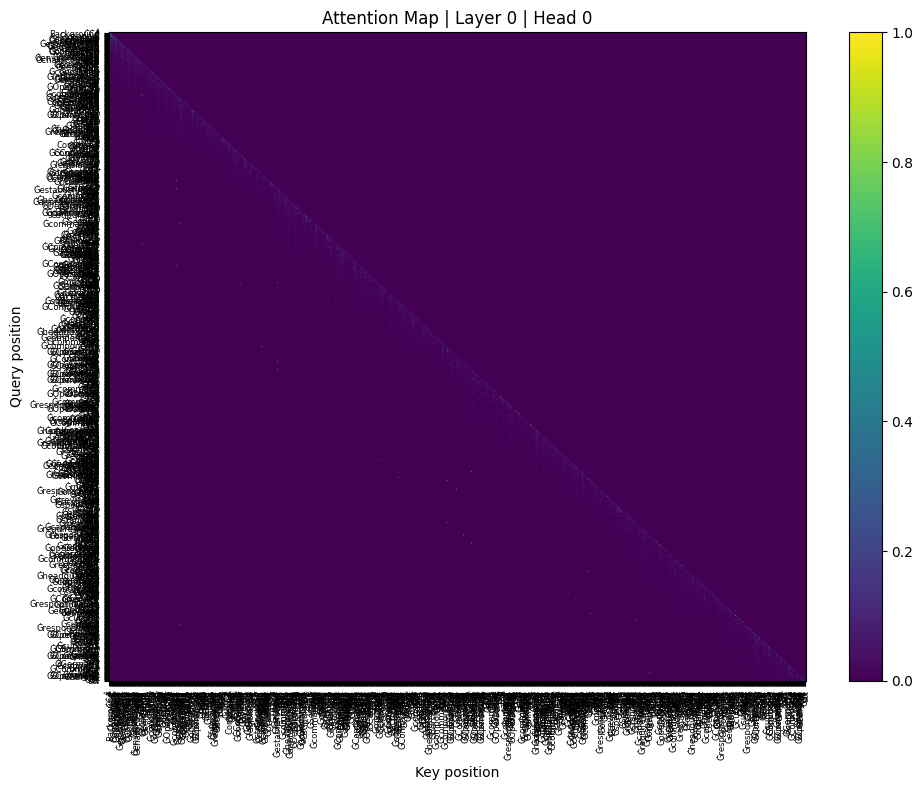

In [28]:
model_name = "EleutherAI/pythia-31m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation="eager"
)
model.eval()

example = scrolls["gov_report"]["validation"][0]

viz_inputs = tokenizer(
    example["input"],
    return_tensors="pt",
    truncation=True,
    max_length=1024,   # keep small enough to visualize clearly
)

with torch.no_grad():
    outputs = model(
        **viz_inputs,
        output_attentions=True
    )

# attentions is a tuple: one tensor per layer
# each tensor has shape [batch_size, num_heads, seq_len, seq_len]
layer_idx = 0
head_idx = 0

attn = outputs.attentions[layer_idx][0, head_idx].cpu()
tokens = tokenizer.convert_ids_to_tokens(viz_inputs["input_ids"][0])

plt.figure(figsize=(10, 8))
plt.imshow(attn, aspect="auto")
plt.colorbar()
plt.title(f"Attention Map | Layer {layer_idx} | Head {head_idx}")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=6)
plt.yticks(range(len(tokens)), tokens, fontsize=6)
plt.tight_layout()
plt.show()


Now, we calculate the baseline PPL loss for Pythia-31m on Wikitext.

In [37]:
import math
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- prepare dataset ONCE (outside function) ---
split = wikitext["test"]
texts = [t for t in split["text"] if t and t.strip()]
full_text = "\n\n".join(texts)

# use any tokenizer (they are identical across Pythia)
base_tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

enc = base_tokenizer(full_text, return_tensors="pt", add_special_tokens=True)
input_ids = enc["input_ids"].to(device)


# --- function ---
def compute_ppl(model_id, input_ids, stride=512):
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
    model.eval()

    max_length = getattr(model.config, "max_position_embeddings", 2048)

    total_nll = 0.0
    total_tokens = 0
    seq_len = input_ids.size(1)

    prev_end = 0

    for start in tqdm(range(0, seq_len, stride), desc=f"PPL {model_id}"):
        end = min(start + max_length, seq_len)
        chunk = input_ids[:, start:end]

        if chunk.size(1) < 2:
            break

        trg_len = end - prev_end
        target_ids = chunk.clone()
        target_ids[:, :-trg_len] = -100

        with torch.no_grad():
            out = model(chunk, labels=target_ids)

        num_valid = (target_ids != -100).sum().item()

        total_nll += out.loss.item() * num_valid
        total_tokens += num_valid

        prev_end = end
        if end == seq_len:
            break

    mean_nll = total_nll / max(total_tokens, 1)
    ppl = math.exp(mean_nll)

    return ppl

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

In [42]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import math
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Models you want (Pythia scaling suite)
PYTHIA_MODELS = [
    "EleutherAI/pythia-14m",
    "EleutherAI/pythia-31m",
    "EleutherAI/pythia-70m",
    "EleutherAI/pythia-160m",
    "EleutherAI/pythia-410m",
    "EleutherAI/pythia-1B",
]

# reuse your tokenized dataset
enc = pythia_tokenizer(full_text, return_tensors="pt", add_special_tokens=True)
input_ids = enc["input_ids"].to(device)

results = []

for model_id in PYTHIA_MODELS:
    print(f"Evaluating {model_id}...")
    ppl = compute_ppl(model_id, input_ids)
    results.append((model_id, ppl))


# nice table
print("\n=== Perplexity Results ===")
print(f"{'Model':<30} {'PPL':>10}")
print("-" * 42)
for model, ppl in results:
    print(f"{model:<30} {ppl:>10.2f}")

Evaluating EleutherAI/pythia-14m...


PPL EleutherAI/pythia-14m:  99%|█████████▉| 559/563 [00:04<00:00, 127.24it/s]


Evaluating EleutherAI/pythia-31m...


PPL EleutherAI/pythia-31m:  99%|█████████▉| 559/563 [00:05<00:00, 105.09it/s]


Evaluating EleutherAI/pythia-70m...


...

Evaluating EleutherAI/pythia-410m...


PPL EleutherAI/pythia-410m:  99%|█████████▉| 559/563 [01:01<00:00,  9.07it/s]


Evaluating EleutherAI/pythia-1B...


PPL EleutherAI/pythia-1B:  99%|█████████▉| 559/563 [02:08<00:00,  4.35it/s]



=== Perplexity Results ===
Model                                 PPL
------------------------------------------
EleutherAI/pythia-14m               80.35
EleutherAI/pythia-31m               50.01
EleutherAI/pythia-70m               37.72
EleutherAI/pythia-160m              22.45
EleutherAI/pythia-410m              13.63
EleutherAI/pythia-1B                11.39


## Finetune last 3 layers (full attention, no weight destruction)

Self-contained: default Hugging Face weights, **no** `reset_parameters` on the top layers (causes loss to explode), **no** sliding-window attention. Only the last 3 blocks + final layer norm + output projection are trained (Pythia/GPT-2).

Uses WikiText for LM. Adjust `FT_CONFIG` as needed.

In [78]:
# 1) Config, device, and seeds for last-3 finetuning (no new_fine_tune import)
import os
import random
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    get_cosine_schedule_with_warmup,
)
from tqdm import tqdm

_cache = globals().get("cache_dir", "./data")
# _mid = "EleutherAI/pythia-14m"
_mid = "EleutherAI/pythia-31m"
# _mid = "EleutherAI/pythia-70m"
# _mid = "EleutherAI/pythia-160m"
# _mid = "EleutherAI/pythia-410m"
# _mid = "EleutherAI/pythia-1bm"
FT_CONFIG = {
    "cache_dir": _cache,
    "model_name": _mid,
    "wikitext_config": "wikitext-2-raw-v1",  # or wikitext-103-raw-v1 (much larger, 103 million tokens)
    "max_length": 512,
    "train_batch_size": 2,
    "eval_batch_size": 2,
    "last_k_layers": 3,
    "num_epochs": 2,
    "lr": 1e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.03,
    "seed": 42,
    "output_dir": "./checkpoints",
    "save_name": "last3_full_attention",
}


#Set a manual seed for reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(FT_CONFIG["seed"])
torch.manual_seed(FT_CONFIG["seed"])
torch.cuda.manual_seed_all(FT_CONFIG["seed"])
os.makedirs(FT_CONFIG["output_dir"], exist_ok=True)
print("device:", device, "| model:", FT_CONFIG["model_name"])


device: cuda | model: EleutherAI/pythia-31m


In [79]:
# 2) Helpers: pack WikiText into fixed-length LM blocks, build loaders, freeze all but last k layers
def group_texts(examples, block_size):
    concatenated = {}
    for k in examples.keys():
        concatenated[k] = sum(examples[k], [])
    total_length = len(concatenated["input_ids"])
    total_length = (total_length // block_size) * block_size
    result = {}
    for k, v in concatenated.items():
        result[k] = [v[i : i + block_size] for i in range(0, total_length, block_size)]
    result["labels"] = result["input_ids"].copy()
    return result


def build_wikitext_loaders(tokenizer, cfg):
    raw = load_dataset("wikitext", cfg["wikitext_config"], cache_dir=cfg["cache_dir"])
    tokenized = raw.map(
        lambda ex: tokenizer(ex["text"], add_special_tokens=False),
        batched=True,
        remove_columns=raw["train"].column_names,
    )
    lm = tokenized.map(
        lambda ex: group_texts(ex, cfg["max_length"]),
        batched=True,
    )
    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
    train_loader = DataLoader(
        lm["train"],
        batch_size=cfg["train_batch_size"],
        shuffle=True,
        collate_fn=collator,
    )
    eval_split = "validation" if "validation" in lm else "test"
    eval_loader = DataLoader(
        lm[eval_split],
        batch_size=cfg["eval_batch_size"],
        shuffle=False,
        collate_fn=collator,
    )
    return train_loader, eval_loader


def freeze_all_but_last_k_layers(model, k):
    """Unfreeze only the last k transformer blocks + final norm + LM head (Pythia or GPT-2)."""
    for p in model.parameters():
        p.requires_grad = False
    if hasattr(model, "gpt_neox") and hasattr(model.gpt_neox, "layers"):
        for layer in model.gpt_neox.layers[-k:]:
            for p in layer.parameters():
                p.requires_grad = True
        if hasattr(model.gpt_neox, "final_layer_norm"):
            for p in model.gpt_neox.final_layer_norm.parameters():
                p.requires_grad = True
        if hasattr(model, "embed_out"):
            for p in model.embed_out.parameters():
                p.requires_grad = True
    elif hasattr(model, "transformer") and hasattr(model.transformer, "h"):
        for layer in model.transformer.h[-k:]:
            for p in layer.parameters():
                p.requires_grad = True
        if hasattr(model.transformer, "ln_f"):
            for p in model.transformer.ln_f.parameters():
                p.requires_grad = True
        if hasattr(model, "lm_head"):
            for p in model.lm_head.parameters():
                p.requires_grad = True
    else:
        raise ValueError("Unsupported model (need Pythia/GPT-NeoX or GPT-2).")


In [80]:
# 3) One training epoch + eval (eval loss / PPL on the eval dataloader)
import math


def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total = 0.0
    for batch in tqdm(dataloader, desc="train", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        loss = out.loss
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total += loss.item()
    return total / len(dataloader)


@torch.no_grad()
def eval_split(model, dataloader, device):
    model.eval()
    total = 0.0
    for batch in tqdm(dataloader, desc="eval", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        total += model(**batch).loss.item()
    avg = total / len(dataloader)
    ppl = math.exp(avg) if avg < 25 else float("inf")
    return avg, ppl


In [82]:
# 4) Load default pretrained weights (float32). No re-init — all weights preserved.
ft_tokenizer = AutoTokenizer.from_pretrained(FT_CONFIG["model_name"], cache_dir=FT_CONFIG["cache_dir"])
if ft_tokenizer.pad_token is None:
    ft_tokenizer.pad_token = ft_tokenizer.eos_token
ft_model = AutoModelForCausalLM.from_pretrained(
    FT_CONFIG["model_name"],
    cache_dir=FT_CONFIG["cache_dir"],
    torch_dtype=torch.float32,
).to(device)

freeze_all_but_last_k_layers(ft_model, FT_CONFIG["last_k_layers"])
trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable)
print(ft_model.config)


Trainable parameters: 15247616
GPTNeoXConfig {
  "_name_or_path": "EleutherAI/pythia-31m",
  "architectures": [
    "GPTNeoXForCausalLM"
  ],
  "attention_bias": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.1,
  "eos_token_id": 0,
  "hidden_act": "gelu",
  "hidden_dropout": 0.0,
  "hidden_size": 256,
  "initializer_range": 0.02,
  "intermediate_size": 1024,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 2048,
  "model_type": "gpt_neox",
  "num_attention_heads": 8,
  "num_hidden_layers": 6,
  "rope_scaling": null,
  "rotary_emb_base": 10000,
  "rotary_pct": 0.25,
  "tie_word_embeddings": false,
  "torch_dtype": "float32",
  "transformers_version": "4.44.2",
  "use_cache": true,
  "use_parallel_residual": true,
  "vocab_size": 50304
}



In [83]:
# 5) WikiText train / eval DataLoaders
train_loader, eval_loader = build_wikitext_loaders(ft_tokenizer, FT_CONFIG)
print("train batches:", len(train_loader), "| eval batches:", len(eval_loader))


Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

Map:   0%|          | 0/4358 [00:00<?, ? examples/s]

Map:   0%|          | 0/36718 [00:00<?, ? examples/s]

Map:   0%|          | 0/3760 [00:00<?, ? examples/s]

train batches: 2344 | eval batches: 243


In [84]:
# 6) Optimizer and cosine schedule (only last-k + head params are in the optimizer)
opt = AdamW(
    [p for p in ft_model.parameters() if p.requires_grad],
    lr=FT_CONFIG["lr"],
    weight_decay=FT_CONFIG["weight_decay"],
)
steps = len(train_loader) * FT_CONFIG["num_epochs"]
warm = int(steps * FT_CONFIG["warmup_ratio"])
sched = get_cosine_schedule_with_warmup(opt, num_warmup_steps=warm, num_training_steps=steps)


In [85]:
# 7) Training loop
for ep in range(FT_CONFIG["num_epochs"]):
    tr = train_one_epoch(ft_model, train_loader, opt, sched, device)
    ev, eppl = eval_split(ft_model, eval_loader, device)
    print(
        f"epoch {ep + 1}/{FT_CONFIG['num_epochs']}  "
        f"train_loss={tr:.4f}  eval_loss={ev:.4f}  eval_ppl={eppl:.4f}"
    )


epoch 1/2  train_loss=3.9532  eval_loss=3.8731  eval_ppl=48.0897


epoch 2/2  train_loss=3.7877  eval_loss=3.8568  eval_ppl=47.3121
